In [1]:
import pandas as pd
import numpy as np
import sys

metadata_fname = "metadata/metadata_wide.tsv"
quants_fname = "data/proteins_normalized_wide.tsv"

metadata = pd.read_csv(metadata_fname, sep='\t', na_values=['NA'])
data = pd.read_csv(quants_fname, sep='\t')
data = data.fillna(0)
protein_names = data['protein'].values

print("Metadata shape:", metadata.shape)
print("Data shape:", data.shape)

Metadata shape: (104, 25)
Data shape: (2575, 105)


Data shape: (86, 2575)
Months: [22.42 14.37 14.37 17.36 11.15  5.85 22.42 29.33 22.42 20.48 17.46  5.85
 14.37  8.15 11.15 22.42 30.25 27.   14.37 20.48  5.85  5.85 27.   17.46
 29.33 11.15 20.48  8.15  8.15 17.46 20.58 11.15 27.   22.42 17.46 11.15
 14.37  5.85  8.15 29.33  8.15 22.42 27.   22.42  5.85 11.15  5.85 22.42
 17.46 30.25 20.48  5.85 20.58 17.36  8.15 14.37  8.15 11.15 14.37 22.42
 17.46  8.15 11.15  5.85 22.42 14.37  5.85 20.48 20.48 27.   20.48 17.46
  8.15 29.33 11.15 22.42 20.48 27.   14.37 30.25 14.37 17.36  8.15 11.15
 27.   22.42]
Sex: [0 0 0 1 0 0 1 0 0 1 0 0 1 0 1 1 1 0 1 0 1 1 1 0 0 1 1 1 0 0 0 0 0 0 1 1 0
 1 1 0 1 1 1 0 0 0 1 1 0 1 0 0 0 1 1 1 0 1 0 0 1 1 0 1 0 1 0 1 1 0 1 0 0 0
 0 1 0 0 0 1 1 1 0 1 1 1]


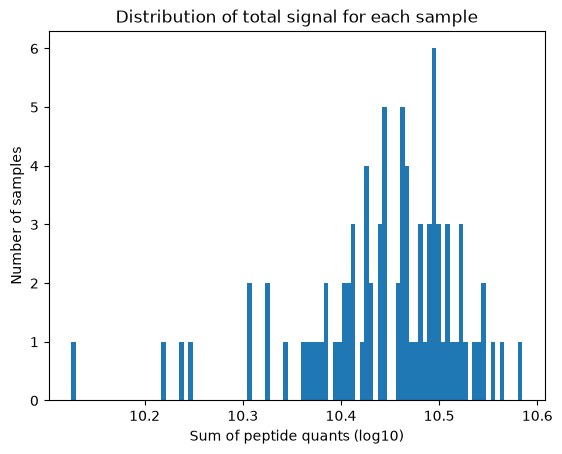

In [2]:
import matplotlib.pyplot as plt

valid_replicates = metadata[metadata['Age_months'].notna()]['replicate'].tolist()

X = []
month = []
sex = []

for idx in valid_replicates:
  for sample in data.columns[:]:
    if idx in sample:
      s_month = metadata[metadata['replicate'] == idx]['Age_months'].values[0]
      s_sex = metadata[metadata['replicate'] == idx]['Sex'].values[0]

      month.append(s_month)
      sex.append(s_sex)
      X.append(data[sample].values)

X = np.array(X)
X = np.power(2, X) # "unlog" X

month = np.array(month)
month = month.astype(float)

sex = np.array(sex)
sex = np.where(sex == "Male", 0, 1) # encode the sex array
sex = sex.astype(int)

print("Data shape:", X.shape)
print("Months:", month)
print("Sex:", sex)

total_signal = np.sum(X, axis=1)
plt.hist(np.log10(total_signal), bins = 100)
plt.title('Distribution of total signal for each sample')
plt.ylabel('Number of samples')
plt.xlabel('Sum of peptide quants (log10)')
plt.show()

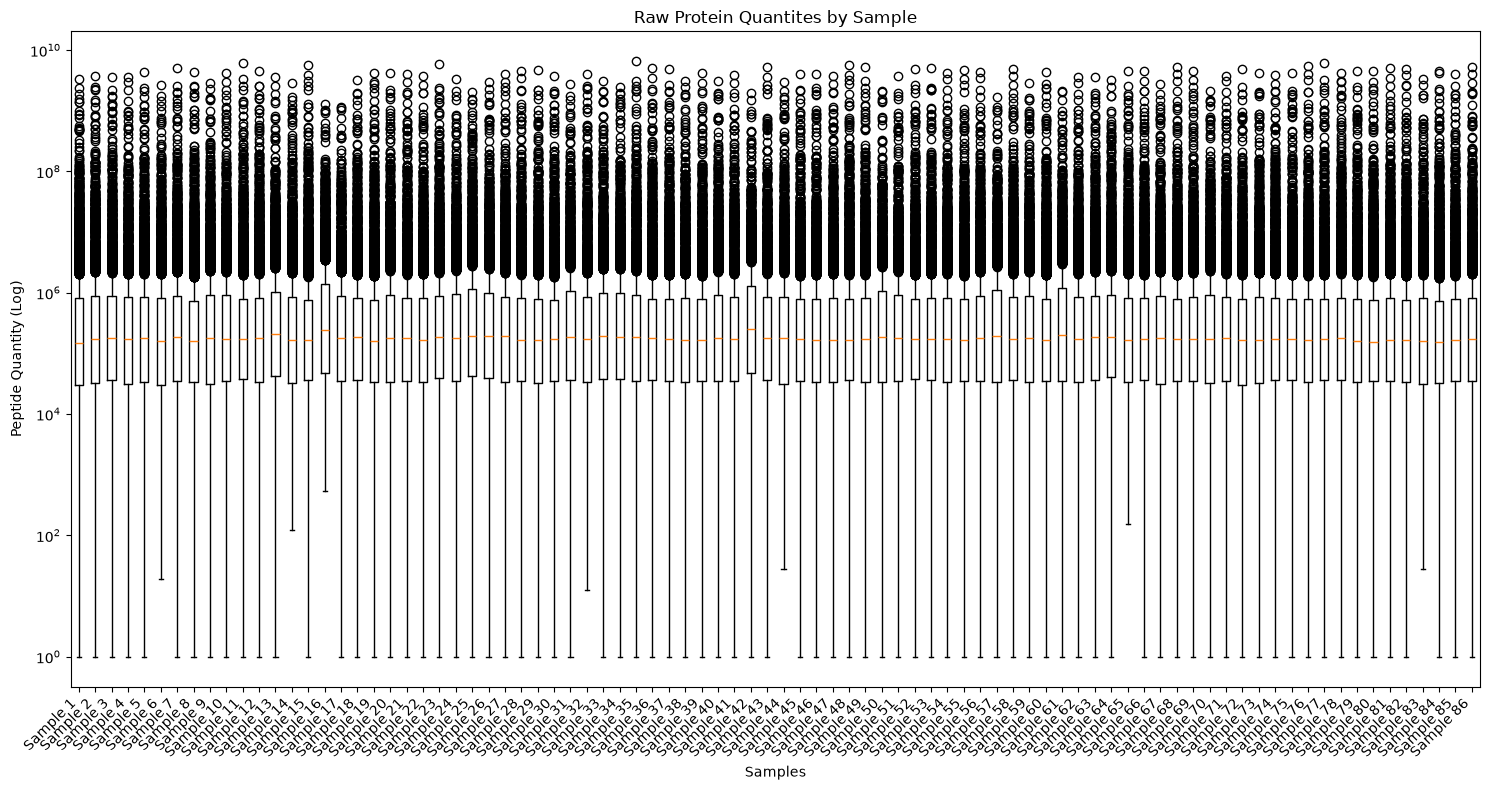

In [3]:
# Create the box plot
plt.figure(figsize=(15, 8))
plt.boxplot(X.T)  # Transpose the data

plt.title('Raw Protein Quantites by Sample')
plt.xlabel('Samples')
plt.ylabel('Peptide Quantity (Log)')
plt.xticks(range(1, X.shape[0] + 1), [f'Sample {i+1}' for i in range(X.shape[0])], rotation=45, ha='right')

# Use log scale for y-axis as peptide quantities often span several orders of magnitude
plt.yscale('log')

plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

In [4]:
from __future__ import annotations
from typing import Dict, Literal, Optional, Union
import numpy as np
from scipy.stats import rankdata, norm, t as student_t
from statsmodels.stats.multitest import multipletests


def spearman_fisherz_sex_diff(
    X: np.ndarray,
    protein_names: np.ndarray,
    sex: np.ndarray,
    timepoint: np.ndarray,
    *,
    male_label: Union[str, int] = "M",
    female_label: Union[str, int] = "F",
    min_n_per_sex: int = 6,
    nan_policy: Literal["pairwise", "complete"] = "pairwise",
    return_type: Literal["dict", "dataframe", "structured"] = "dict",
) -> Union[Dict[str, np.ndarray], "np.ndarray", "pd.DataFrame"]:
    """
    Compute (per protein):
      - global Spearman rho (all samples vs timepoint) + approx p-value
      - sex-specific Spearman rhos (male, female) + approx p-values
      - Fisher z-test for difference between sex-specific rhos (independent groups)
      - p_diff and BH-FDR across proteins for p_diff

    This is faster than calling scipy.stats.spearmanr in a loop because it computes
    Spearman as Pearson correlation of ranks and uses a lightweight correlation/p-value
    calculation. Complexity is ~O(P * N log N) dominated by rank computations.

    Parameters
    ----------
    X : (n_samples, n_proteins) array
    protein_names : (n_proteins,) array of labels
    sex : (n_samples,) array of labels. Supports string labels (e.g. "M"/"F") or
        integer-encoded labels (e.g. 0/1). male_label and female_label must match
        the dtype used (e.g. male_label=1, female_label=0 for integer encoding).
    timepoint : (n_samples,) numeric array (age/time)
    male_label / female_label : labels identifying sexes in `sex`. Can be str or int.
        For integer-encoded sex, pass e.g. male_label=1, female_label=0.
    min_n_per_sex : minimum valid N per sex required to compute z-diff.
        A hard floor of 4 is also enforced because Fisher z requires n-3 > 0.
    nan_policy :
        - "pairwise": per protein, drop rows where X[:,j] or timepoint is non-finite
        - "complete": drop rows where any protein OR timepoint is non-finite (strict)
    return_type :
        - "dict": returns dict of numpy arrays
        - "structured": returns structured numpy array
        - "dataframe": returns pandas DataFrame (requires pandas)

    Notes on p-values
    -----------------
    The Spearman p-values here use a common large-sample approximation:
      treat Spearman rho like Pearson r on ranks and use a t-test with df = n-2.
    This is typically fine for screening thousands of proteins. If you need exact
    p-values for small n, you can swap in scipy.stats.spearmanr per protein.

    Notes on n_all vs n_male + n_female
    ------------------------------------
    In pairwise mode, n_all reflects finite rows across all samples for protein j.
    If any samples have a sex label other than male_label or female_label (e.g.
    "unknown"), n_male + n_female may be less than n_all. This is expected.
    Protein names longer than 256 characters will be silently truncated in the
    structured array return type.

    Returns
    -------
    Per-protein statistics including:
      protein, n_all, n_male, n_female,
      rho_all, p_all,
      rho_male, p_male,
      rho_female, p_female,
      z_diff, p_diff, fdr_diff
    """
    X = np.asarray(X)
    protein_names = np.asarray(protein_names)
    timepoint = np.asarray(timepoint, dtype=float)

    # Normalise sex array: if integer labels are provided, cast sex to the same
    # integer dtype so that equality comparisons work correctly regardless of
    # whether the caller passes a bool, int8, int64, etc. array.
    sex = np.asarray(sex)
    if isinstance(male_label, (int, np.integer)) or isinstance(female_label, (int, np.integer)):
        # Coerce both the array and the labels to a consistent integer type so
        # that, e.g., sex dtype int8 doesn't silently fail to match a Python int.
        sex = sex.astype(int)
        male_label = int(male_label)
        female_label = int(female_label)

    if X.ndim != 2:
        raise ValueError(f"X must be 2D (n_samples, n_proteins); got {X.shape}")
    n_samples, n_proteins = X.shape

    if protein_names.ndim != 1 or protein_names.shape[0] != n_proteins:
        raise ValueError(
            f"protein_names must be 1D length {n_proteins}; got {protein_names.shape}"
        )
    if sex.ndim != 1 or sex.shape[0] != n_samples:
        raise ValueError(f"sex must be 1D length {n_samples}; got {sex.shape}")
    if timepoint.ndim != 1 or timepoint.shape[0] != n_samples:
        raise ValueError(f"timepoint must be 1D length {n_samples}; got {timepoint.shape}")

    male_mask = (sex == male_label)
    female_mask = (sex == female_label)

    if not np.any(male_mask):
        raise ValueError(f"No samples match male_label={male_label!r}")
    if not np.any(female_mask):
        raise ValueError(f"No samples match female_label={female_label!r}")
    if nan_policy not in ("pairwise", "complete"):
        raise ValueError("nan_policy must be 'pairwise' or 'complete'")

    # Optionally drop rows up-front (strict)
    if nan_policy == "complete":
        row_ok = np.isfinite(timepoint) & np.all(np.isfinite(X), axis=1)
        Xw = X[row_ok]
        tw = timepoint[row_ok]
        sexw = sex[row_ok]
        male_mask_w = (sexw == male_label)
        female_mask_w = (sexw == female_label)
    else:
        Xw = X
        tw = timepoint
        sexw = sex
        male_mask_w = male_mask
        female_mask_w = female_mask

    # ---------- helpers ----------

    def _corr_and_p_from_vectors(x: np.ndarray, y: np.ndarray) -> tuple[float, float, int]:
        """
        Compute Spearman rho by:
          - mask finite
          - rank x and y
          - Pearson correlation on ranks
          - approximate p-value using t-test with df=n-2
        Returns (rho, p, n_used)
        """
        m = np.isfinite(x) & np.isfinite(y)
        n = int(m.sum())
        if n < 3:
            return (np.nan, np.nan, n)
        xv = x[m]
        yv = y[m]
        # If constant, correlation undefined
        if np.all(xv == xv[0]) or np.all(yv == yv[0]):
            return (np.nan, np.nan, n)
        rx = rankdata(xv, method="average")
        ry = rankdata(yv, method="average")
        # Pearson correlation of ranks
        rx_mean = rx.mean()
        ry_mean = ry.mean()
        rx0 = rx - rx_mean
        ry0 = ry - ry_mean
        denom = np.sqrt(np.sum(rx0 * rx0) * np.sum(ry0 * ry0))
        if denom == 0:
            return (np.nan, np.nan, n)
        r = float(np.sum(rx0 * ry0) / denom)
        # Approx p-value via t statistic (common approximation)
        # t = r * sqrt((n-2)/(1-r^2)), df=n-2
        # Protect against tiny numerical issues at |r| ~ 1
        r_clamped = np.clip(r, -0.999999999, 0.999999999)
        t_stat = r_clamped * np.sqrt((n - 2) / max(1e-30, (1.0 - r_clamped * r_clamped)))
        p = float(2.0 * student_t.sf(np.abs(t_stat), df=n - 2))
        return (r, p, n)

    def _fisher_z(r: float) -> float:
        if not np.isfinite(r):
            return np.nan
        r = np.clip(r, -0.999999999, 0.999999999)
        return 0.5 * np.log((1.0 + r) / (1.0 - r))

    # ---------- allocate outputs ----------
    protein_str = protein_names.astype(str)
    n_all = np.zeros(n_proteins, dtype=int)
    n_male = np.zeros(n_proteins, dtype=int)
    n_female = np.zeros(n_proteins, dtype=int)
    rho_all = np.full(n_proteins, np.nan, dtype=float)
    p_all = np.full(n_proteins, np.nan, dtype=float)
    rho_m = np.full(n_proteins, np.nan, dtype=float)
    p_m = np.full(n_proteins, np.nan, dtype=float)
    rho_f = np.full(n_proteins, np.nan, dtype=float)
    p_f = np.full(n_proteins, np.nan, dtype=float)
    z_diff = np.full(n_proteins, np.nan, dtype=float)
    p_diff = np.full(n_proteins, np.nan, dtype=float)

    # ---------- main loop (fast rank + corr; avoids scipy spearmanr overhead) ----------
    # Pre-slice group arrays once (saves repeated boolean indexing per protein)
    Xm = Xw[male_mask_w, :]
    tm = tw[male_mask_w]
    Xf = Xw[female_mask_w, :]
    tf = tw[female_mask_w]

    # Fisher z-diff requires n >= 4 in each group (so that n-3 > 0). We also
    # respect the caller-supplied min_n_per_sex, taking whichever is stricter.
    _min_n = max(min_n_per_sex, 4)

    for j in range(n_proteins):
        xj = Xw[:, j]
        r, p, n = _corr_and_p_from_vectors(xj, tw)
        rho_all[j], p_all[j], n_all[j] = r, p, n

        r_m, p_mj, nm = _corr_and_p_from_vectors(Xm[:, j], tm)
        rho_m[j], p_m[j], n_male[j] = r_m, p_mj, nm

        r_f, p_fj, nf = _corr_and_p_from_vectors(Xf[:, j], tf)
        rho_f[j], p_f[j], n_female[j] = r_f, p_fj, nf

        # Fisher z-difference test between independent correlations
        # Z = (z_m - z_f) / sqrt(1/(n_m-3) + 1/(n_f-3))
        if (
            np.isfinite(r_m) and np.isfinite(r_f)
            and nm >= _min_n
            and nf >= _min_n
        ):
            zm = _fisher_z(r_m)
            zf = _fisher_z(r_f)
            se = np.sqrt(1.0 / (nm - 3.0) + 1.0 / (nf - 3.0))
            if np.isfinite(zm) and np.isfinite(zf) and se > 0:
                z = (zm - zf) / se
                # Use norm.sf for better numerical precision in the extreme tails
                # compared to 1 - norm.cdf.
                pz = float(2.0 * norm.sf(np.abs(z)))
                z_diff[j] = z
                p_diff[j] = pz

    # ---------- BH-FDR using a standard library ----------
    fdr_diff = np.full(n_proteins, np.nan, dtype=float)
    ok = np.isfinite(p_diff)
    if np.any(ok):
        # multipletests returns: reject, pvals_corrected, alphacSidak, alphacBonf
        _, p_corr, _, _ = multipletests(p_diff[ok], method="fdr_bh")
        fdr_diff[ok] = p_corr

    # ---------- package results ----------
    if return_type == "dict":
        return {
            "protein": protein_str,
            "n_all": n_all,
            "n_male": n_male,
            "n_female": n_female,
            "rho_all": rho_all,
            "p_all": p_all,
            "rho_male": rho_m,
            "p_male": p_m,
            "rho_female": rho_f,
            "p_female": p_f,
            "z_diff": z_diff,
            "p_diff": p_diff,
            "fdr_diff": fdr_diff,
        }

    if return_type == "structured":
        dtype = np.dtype([
            ("protein", "U256"),
            ("n_all", "i4"),
            ("n_male", "i4"),
            ("n_female", "i4"),
            ("rho_all", "f8"),
            ("p_all", "f8"),
            ("rho_male", "f8"),
            ("p_male", "f8"),
            ("rho_female", "f8"),
            ("p_female", "f8"),
            ("z_diff", "f8"),
            ("p_diff", "f8"),
            ("fdr_diff", "f8"),
        ])
        out = np.zeros(n_proteins, dtype=dtype)
        out["protein"] = protein_str
        out["n_all"] = n_all
        out["n_male"] = n_male
        out["n_female"] = n_female
        out["rho_all"] = rho_all
        out["p_all"] = p_all
        out["rho_male"] = rho_m
        out["p_male"] = p_m
        out["rho_female"] = rho_f
        out["p_female"] = p_f
        out["z_diff"] = z_diff
        out["p_diff"] = p_diff
        out["fdr_diff"] = fdr_diff
        return out

    if return_type == "dataframe":
        import pandas as pd  # standard in most scientific stacks
        return pd.DataFrame({
            "protein": protein_str,
            "n_all": n_all,
            "n_male": n_male,
            "n_female": n_female,
            "rho_all": rho_all,
            "p_all": p_all,
            "rho_male": rho_m,
            "p_male": p_m,
            "rho_female": rho_f,
            "p_female": p_f,
            "z_diff": z_diff,
            "p_diff": p_diff,
            "fdr_diff": fdr_diff,
        })

    raise ValueError("return_type must be one of: 'dict', 'structured', 'dataframe'")

In [5]:
stats = spearman_fisherz_sex_diff(
    X,
    protein_names=protein_names,
    sex=sex,
    timepoint=month,
    male_label=0,
    female_label=1,
    min_n_per_sex=6,
    nan_policy="pairwise",
    return_type="dataframe",  # or "dict"/"structured"
)

# Example: top sex-difference hits
top = stats.sort_values(["fdr_diff", "p_diff"]).head(50)
top

,protein,n_all,n_male,n_female,rho_all,p_all,rho_male,p_male,rho_female,p_female,z_diff,p_diff,fdr_diff
120,sp|O35536|TFPI2_MOUSE,86,44,42,0.239363,2.644203e-02,-0.010489,9.461230e-01,0.839829,3.605689e-12,-5.503854,3.715773e-08,0.000096
350,sp|P08003|PDIA4_MOUSE,86,44,42,0.422994,4.960772e-05,-0.061022,6.939610e-01,0.777792,1.360279e-09,-4.921630,8.582628e-07,0.001105
83,sp|O08842|GFRA2_MOUSE,86,44,42,0.034863,7.499758e-01,0.479384,9.933227e-04,-0.418366,5.829474e-03,4.327199,1.510173e-05,0.011012
162,sp|O55111|DSG2_MOUSE,86,44,42,0.012342,9.102019e-01,0.421835,4.344210e-03,-0.471354,1.627881e-03,4.299655,1.710640e-05,0.011012
2457,tr|A2CEK7|A2CEK7_MOUSE,86,44,42,-0.130942,2.294715e-01,-0.629138,4.781500e-06,0.206574,1.893306e-01,-4.245319,2.182825e-05,0.011242
1280,sp|Q68SA9|ATS7_MOUSE,86,44,42,-0.097483,3.718980e-01,0.381154,1.068989e-02,-0.478936,1.333373e-03,4.126545,3.682544e-05,0.012131
626,sp|P42703|LIFR_MOUSE,86,44,42,-0.116001,2.875086e-01,-0.494763,6.400649e-04,0.362442,1.833219e-02,-4.122213,3.752498e-05,0.012131
169,sp|O55189|AMBN_MOUSE,86,44,42,0.301918,4.725939e-03,0.688530,2.392636e-07,-0.071249,6.538759e-01,4.097545,4.175557e-05,0.012131
1579,sp|Q8CGN5|PLIN1_MOUSE,86,44,42,-0.002106,9.846461e-01,-0.469107,1.317565e-03,0.385757,1.163426e-02,-4.093996,4.240024e-05,0.012131
355,sp|P08113|ENPL_MOUSE,86,44,42,0.334703,1.633471e-03,-0.047910,7.574525e-01,0.690401,4.208703e-07,-4.008773,6.103508e-05,0.015717


In [6]:
from __future__ import annotations

from typing import Optional, Tuple, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import rankdata, t as _t_dist


def short_protein_label(name):
    """Reduce a UniProt-style id to just the protein name.

    e.g. 'sp|Q8CGN5|PLIN1_MOUSE' -> 'PLIN1', 'tr|A2CEK7|A2CEK7_MOUSE' -> 'A2CEK7'.
    Protein groups joined by ' / ' are reduced member-by-member.
    """
    labels = []
    for member in str(name).split(' / '):
        parts = member.split('|')
        entry = parts[2] if len(parts) >= 3 else member  # e.g. PLIN1_MOUSE
        labels.append(entry.split('_')[0])  # strip the _MOUSE species suffix
    return ' / '.join(labels)


def visualize_sex_diff(
    results: pd.DataFrame,
    X: np.ndarray,
    protein_names: np.ndarray,
    sex: np.ndarray,
    timepoint: np.ndarray,
    *,
    fdr_cutoff: float = 0.05,
    male_label: Union[str, int] = "M",
    female_label: Union[str, int] = "F",
    male_color: str = "#7B2D8E",
    female_color: str = "#2E8B57",
    log2: bool = False,
    plots_per_row: int = 3,
    point_alpha: float = 0.65,
    point_size: float = 25.0,
    line_alpha: float = 0.9,
    ci: float = 0.95,
    band_alpha: float = 0.15,
    figsize_per_panel: Tuple[float, float] = (3.8, 3.2),
    suptitle: Optional[str] = None,
    base_filename: Optional[str] = None,
    dpi: int = 150,
) -> plt.Figure:
    """
    Visualize per-protein sex-difference results from ``spearman_fisherz_sex_diff``.

    For each protein whose FDR (fdr_diff) is <= ``fdr_cutoff``, one panel is drawn
    showing:
      - Male / female scatter points (timepoint on x, protein abundance on y)
      - A LOWESS-free linear trend line per sex (OLS on the raw / log2-transformed
        values, purely for visual guidance — not the Spearman rho line), with a
        shaded 95% confidence band for the mean response
      - Title block with protein name, sex-specific Spearman rhos, and FDR

    Parameters
    ----------
    results : pd.DataFrame
        Output of ``spearman_fisherz_sex_diff(..., return_type="dataframe")``.
        Must contain columns: protein, rho_male, rho_female, fdr_diff.
    X : (n_samples, n_proteins) array
        Raw abundance matrix — same object passed to the stats function.
    protein_names : (n_proteins,) array-like
        Protein labels — same object passed to the stats function.
    sex : (n_samples,) array-like
        Sex labels — same object passed to the stats function.
    timepoint : (n_samples,) array-like
        Timepoints — same object passed to the stats function.
    fdr_cutoff : float
        Only proteins with fdr_diff <= this value are plotted.
    male_label / female_label : str or int
        Labels used to identify sexes in ``sex``.
    male_color / female_color : str
        Any matplotlib-compatible colour string, including hex codes
        (e.g. "#7B2D8E"), named colours ("purple"), or RGB tuples.
    log2 : bool
        If True, apply log2(x + 1) transformation to the abundance values before
        plotting. The Spearman rho annotations always reflect the values computed
        by the stats function (not re-computed here).
    plots_per_row : int
        Number of panels per row in the figure grid.
    point_alpha : float
        Opacity for scatter points (0–1).
    point_size : float
        Size for scatter points (matplotlib ``s`` parameter).
    line_alpha : float
        Opacity for trend lines (0–1).
    ci : float
        Confidence level for the band shaded around each per-sex OLS trend line
        (0.95 → a 95% CI for the mean response, matching the individual-protein
        panel further down the notebook).
    band_alpha : float
        Opacity for the confidence-interval band (0–1).
    figsize_per_panel : (width, height)
        Size in inches for each individual panel.
    suptitle : str, optional
        Overall figure title. Defaults to an auto-generated string.
    base_filename : str, optional
        If provided, the figure is saved as ``<base_filename>.svg``,
        ``<base_filename>.pdf``, and ``<base_filename>.png``.  Any existing
        file extension on the string is stripped before appending the format
        suffixes.
    dpi : int
        Resolution used when saving raster formats (PNG).

    Returns
    -------
    matplotlib.figure.Figure
        The figure object (also displayed if in an interactive / notebook context).

    Examples
    --------
    >>> fig = visualize_sex_diff(
    ...     results=df_results,
    ...     X=X,
    ...     protein_names=protein_names,
    ...     sex=sex,
    ...     timepoint=timepoint,
    ...     fdr_cutoff=0.10,
    ...     male_color="#4A0072",
    ...     female_color="#00695C",
    ...     log2=True,
    ...     plots_per_row=4,
    ...     base_filename="sex_diff_plots",
    ... )
    """
    # ------------------------------------------------------------------ #
    # 0.  Coerce inputs
    # ------------------------------------------------------------------ #
    X = np.asarray(X, dtype=float)
    protein_names = np.asarray(protein_names)
    sex = np.asarray(sex)
    timepoint = np.asarray(timepoint, dtype=float)

    # Mirror the integer-label normalisation from the stats function
    if isinstance(male_label, (int, np.integer)) or isinstance(female_label, (int, np.integer)):
        sex = sex.astype(int)
        male_label = int(male_label)
        female_label = int(female_label)

    # ------------------------------------------------------------------ #
    # 1.  Filter results to significant proteins, preserving FDR order
    # ------------------------------------------------------------------ #
    sig = results[results["fdr_diff"] <= fdr_cutoff].copy()
    sig = sig.sort_values("fdr_diff")

    if sig.empty:
        raise ValueError(
            f"No proteins pass fdr_cutoff={fdr_cutoff}. "
            "Try a larger cutoff or check that 'fdr_diff' column is present."
        )

    # Map protein name → column index in X
    pname_to_idx = {str(p): i for i, p in enumerate(protein_names)}

    missing = [p for p in sig["protein"].astype(str) if p not in pname_to_idx]
    if missing:
        raise ValueError(
            f"{len(missing)} protein(s) in results not found in protein_names: "
            f"{missing[:5]}{'...' if len(missing) > 5 else ''}"
        )

    # ------------------------------------------------------------------ #
    # 2.  Build figure grid
    # ------------------------------------------------------------------ #
    n_panels = len(sig)
    n_cols = max(1, plots_per_row)
    n_rows = int(np.ceil(n_panels / n_cols))

    fig_w = figsize_per_panel[0] * n_cols
    fig_h = figsize_per_panel[1] * n_rows

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(fig_w, fig_h),
        squeeze=False,
    )

    # ------------------------------------------------------------------ #
    # 3.  Sex masks
    # ------------------------------------------------------------------ #
    male_mask = (sex == male_label)
    female_mask = (sex == female_label)

    t_male = timepoint[male_mask]
    t_female = timepoint[female_mask]

    # ------------------------------------------------------------------ #
    # 4.  Helper: OLS trend line + confidence band
    # ------------------------------------------------------------------ #
    def _ols_line(
        tx: np.ndarray,
        yx: np.ndarray,
    ) -> Optional[Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]]:
        """
        Return (x_line, y_line, lower, upper) for an OLS fit through the finite
        (tx, yx) pairs, spanning the observed x range with 200 points.

        ``lower`` / ``upper`` bound the ``ci`` confidence band for the *mean
        response* (i.e. the regression line itself, not a prediction interval).
        Returns None when there are too few points, or no spread in x, to fit.
        """
        m = np.isfinite(tx) & np.isfinite(yx)
        tx_f = tx[m]
        yx_f = yx[m]
        n = tx_f.size
        if n < 3:
            return None
        xbar = tx_f.mean()
        sxx = np.sum((tx_f - xbar) ** 2)
        if sxx == 0:
            return None
        # Fit degree-1 polynomial (OLS)
        slope, intercept = np.polyfit(tx_f, yx_f, 1)
        dof = n - 2
        resid = yx_f - (intercept + slope * tx_f)
        s_err = np.sqrt(np.sum(resid ** 2) / dof)          # residual standard error
        tval = _t_dist.ppf(0.5 + ci / 2.0, dof)            # two-sided critical value
        x_line = np.linspace(tx_f.min(), tx_f.max(), 200)
        y_line = intercept + slope * x_line
        half = tval * s_err * np.sqrt(1.0 / n + (x_line - xbar) ** 2 / sxx)
        return x_line, y_line, y_line - half, y_line + half

    # ------------------------------------------------------------------ #
    # 5.  Draw panels
    # ------------------------------------------------------------------ #
    def _fmt_rho(val) -> str:
        try:
            return f"{float(val):.3f}"
        except (TypeError, ValueError):
            return "nan"

    def _fmt_fdr(val) -> str:
        try:
            v = float(val)
            if v < 0.001:
                return f"{v:.2e}"
            return f"{v:.4f}"
        except (TypeError, ValueError):
            return "nan"

    axes_flat = axes.flatten()

    for ax_idx, (_, row) in enumerate(sig.iterrows()):
        ax = axes_flat[ax_idx]
        pname = str(row["protein"])
        col_idx = pname_to_idx[pname]

        y_all = X[:, col_idx].copy()
        if log2:
            # log2(x + 1) — safe for zero / near-zero values
            y_all = np.log2(np.maximum(y_all, 0) + 1)

        y_male = y_all[male_mask]
        y_female = y_all[female_mask]

        # ---- scatter ------------------------------------------------- #
        ax.scatter(
            t_male, y_male,
            color=male_color, alpha=point_alpha, s=point_size,
            label=f"Male (ρ={_fmt_rho(row['rho_male'])})",
            zorder=3, linewidths=0,
        )
        ax.scatter(
            t_female, y_female,
            color=female_color, alpha=point_alpha, s=point_size,
            label=f"Female (ρ={_fmt_rho(row['rho_female'])})",
            zorder=3, linewidths=0,
        )

        # ---- trend lines + confidence bands --------------------------- #
        for (t_grp, y_grp, grp_color) in (
            (t_male, y_male, male_color),
            (t_female, y_female, female_color),
        ):
            fit = _ols_line(t_grp, y_grp)
            if fit is None:
                continue
            x_line, y_line, lo, hi = fit
            ax.fill_between(x_line, lo, hi, color=grp_color, alpha=band_alpha,
                            linewidth=0, zorder=1)
            ax.plot(x_line, y_line, color=grp_color, alpha=line_alpha,
                    linewidth=1.8, zorder=4)

        # ---- annotations --------------------------------------------- #
        fdr_str = _fmt_fdr(row["fdr_diff"])
        ax.set_title(
            f"{short_protein_label(pname)}\n"
            f"ρ♂={_fmt_rho(row['rho_male'])}  ρ♀={_fmt_rho(row['rho_female'])}\n"
            f"FDR={fdr_str}",
            fontsize=12, loc="left", pad=4,
        )

        ax.set_xlabel("Timepoint", fontsize=14)
        y_label = "log₂(abundance + 1)" if log2 else "Abundance"
        ax.set_ylabel(y_label, fontsize=14)
        ax.tick_params(labelsize=12)
        # ax.legend(fontsize=6, framealpha=0.6, loc="best")
        ax.spines[["top", "right"]].set_visible(False)

    # ------------------------------------------------------------------ #
    # 6.  Hide unused axes
    # ------------------------------------------------------------------ #
    for ax_idx in range(n_panels, len(axes_flat)):
        axes_flat[ax_idx].set_visible(False)

    # ------------------------------------------------------------------ #
    # 7.  Figure-level title and layout
    # ------------------------------------------------------------------ #
    fig.tight_layout()

    # ------------------------------------------------------------------ #
    # 8.  Save as SVG, PDF, and PNG
    # ------------------------------------------------------------------ #
    if base_filename is not None:
        import os
        # Strip any existing extension from the base filename
        base, _ = os.path.splitext(base_filename)
        for ext in ("svg", "pdf", "png"):
            fig.savefig(
                f"{base}.{ext}",
                dpi=dpi,
                bbox_inches="tight",
                format=ext,
            )

    return fig

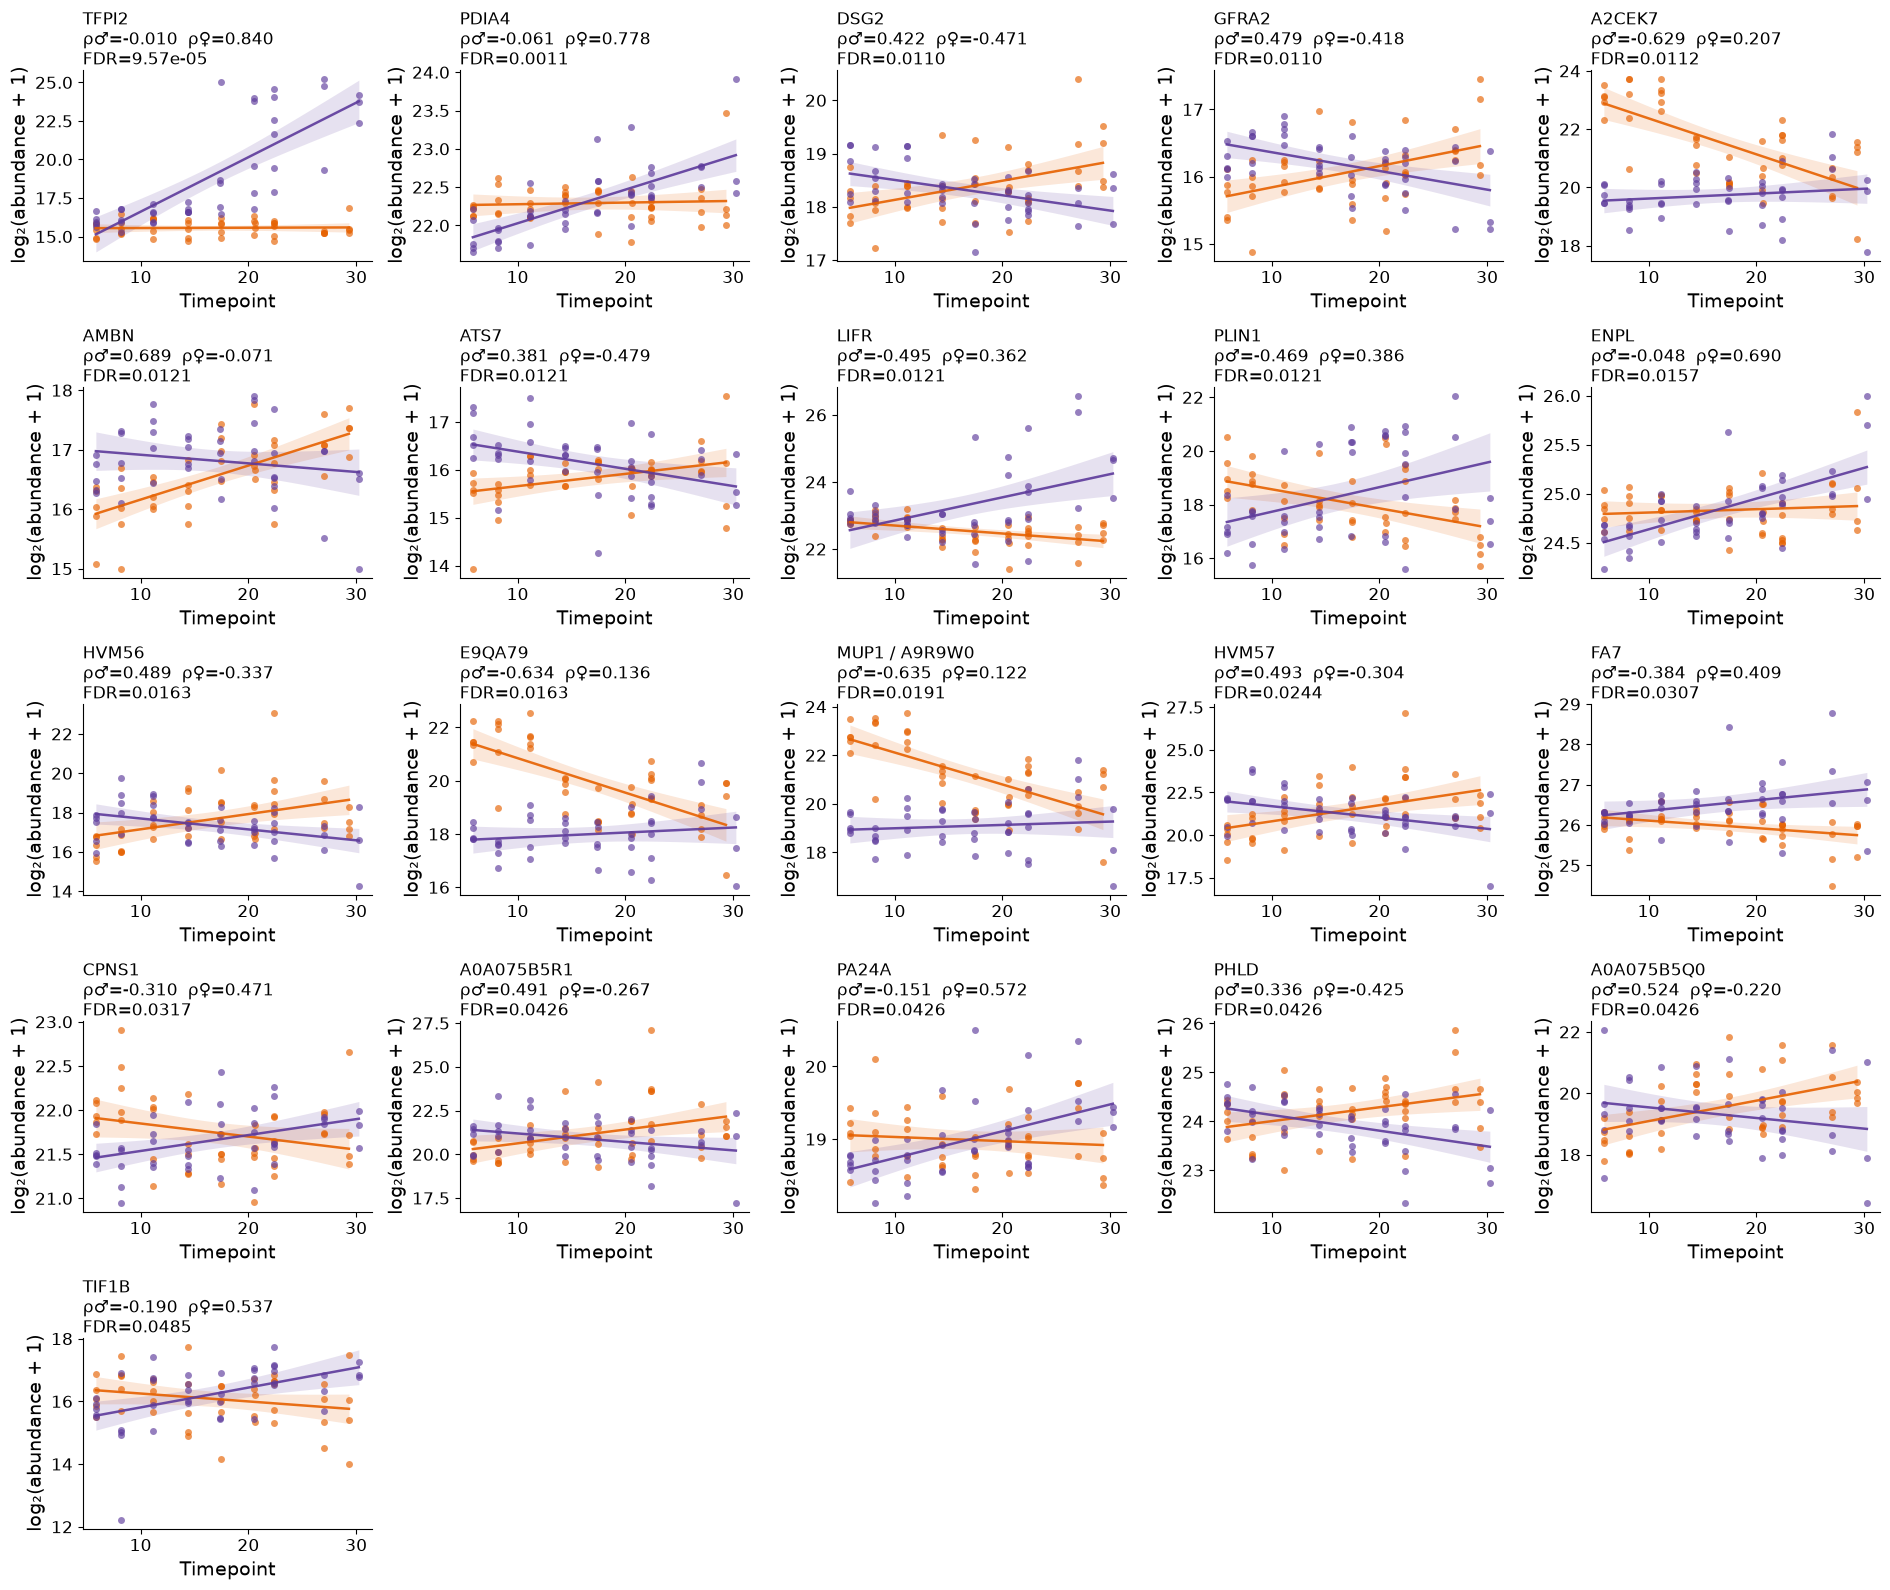

In [7]:
fig = visualize_sex_diff(
    results=stats,          # dataframe from the stats function
    X=X,                 # same abundance matrix
    protein_names=protein_names,   # same protein names array
    sex=sex,             # same sex array
    timepoint=month, # same timepoint array
    fdr_cutoff=0.05,
    log2=True,
    plots_per_row=5,
    male_label=0,
    female_label=1,
    male_color='#E66100',
    female_color='#5D3A9B',
    base_filename="results/sex-discordant-proteins-by-spearman-rho"
)

In [8]:
stats.sort_values("fdr_diff").to_csv("results/protein-sex-discordant-spearman-rho.csv", index=False)
print(f"Saved {len(stats)} rows to results/protein-sex-discordant-spearman-rho.csv")


Saved 2575 rows to results/protein-sex-discordant-spearman-rho.csv


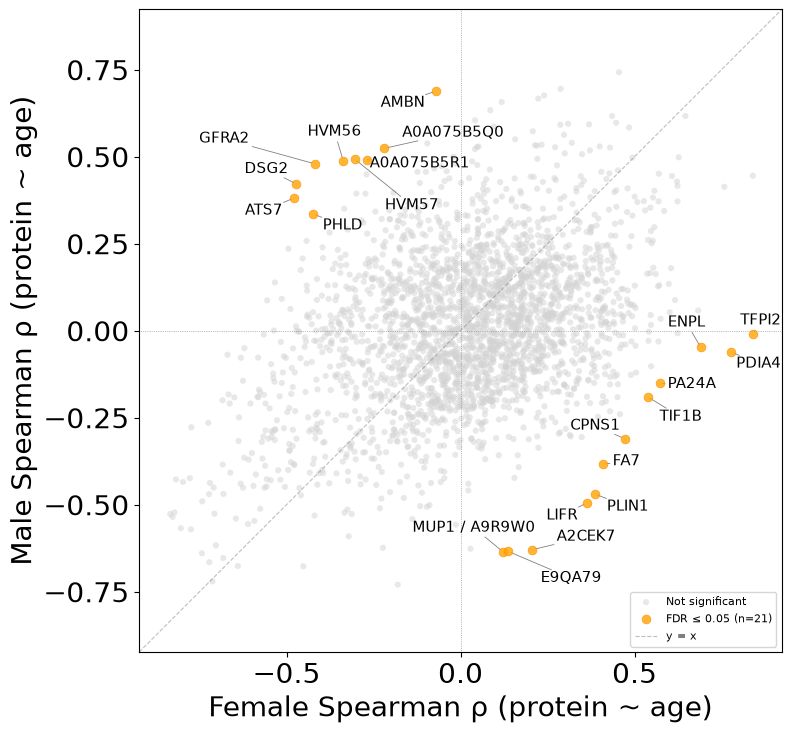

In [9]:
from adjustText import adjust_text


def short_protein_label(name):
    """Reduce a UniProt-style id to just the protein name.

    e.g. 'sp|Q8CGN5|PLIN1_MOUSE' -> 'PLIN1', 'tr|A2CEK7|A2CEK7_MOUSE' -> 'A2CEK7'.
    Protein groups joined by ' / ' are reduced member-by-member.
    """
    labels = []
    for member in str(name).split(' / '):
        parts = member.split('|')
        entry = parts[2] if len(parts) >= 3 else member  # e.g. PLIN1_MOUSE
        labels.append(entry.split('_')[0])  # strip the _MOUSE species suffix
    return ' / '.join(labels)


fig, ax = plt.subplots(figsize=(8, 8))

sig_mask = stats['fdr_diff'] <= 0.05

# Plot non-significant points
ax.scatter(
    stats.loc[~sig_mask, 'rho_female'],
    stats.loc[~sig_mask, 'rho_male'],
    c='lightgray', s=20, alpha=0.5, edgecolors='none',
    label='Not significant',
)

# Plot significant points
ax.scatter(
    stats.loc[sig_mask, 'rho_female'],
    stats.loc[sig_mask, 'rho_male'],
    c='orange', s=40, alpha=0.8, edgecolors='darkorange', linewidths=0.5,
    label=f'FDR ≤ 0.05 (n={sig_mask.sum()})',
    zorder=3,
)

# Label significant points with adjust_text to avoid overlaps
texts = []
for _, row in stats.loc[sig_mask].iterrows():
    texts.append(
        ax.text(row['rho_female'], row['rho_male'], short_protein_label(row['protein']),
                fontsize=10.5, ha='center', va='center')
    )

# Repel labels from each other AND from the significant points (passed as x/y)
# so no label is drawn on top of a point; a connector line ties each label to
# its point, keeping the mapping unambiguous.
adjust_text(
    texts,
    x=stats.loc[sig_mask, 'rho_female'].values,
    y=stats.loc[sig_mask, 'rho_male'].values,
    ax=ax,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.6),
    expand=(1.5, 1.8),
    force_text=(0.5, 0.8),
    force_static=(0.5, 0.7),
    min_arrow_len=1,
)

# Reference lines
lim = max(abs(ax.get_xlim()[0]), abs(ax.get_xlim()[1]),
          abs(ax.get_ylim()[0]), abs(ax.get_ylim()[1]))
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.plot([-lim, lim], [-lim, lim], ls='--', c='gray', lw=0.8, alpha=0.5, label='y = x')
ax.axhline(0, ls=':', c='gray', lw=0.5)
ax.axvline(0, ls=':', c='gray', lw=0.5)

ax.set_xlabel('Female Spearman ρ (protein ~ age)', fontsize=20)
ax.set_ylabel('Male Spearman ρ (protein ~ age)', fontsize=20)
ax.tick_params(axis='both', labelsize=20)
ax.legend(loc='lower right', fontsize=8)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

BH correction applied within each sex across 2574 proteins (all proteins except sp|P00924|ENO1_YEAST)


Saved panel to results/aging-marker-proteins-by-sex.{svg,pdf,png}


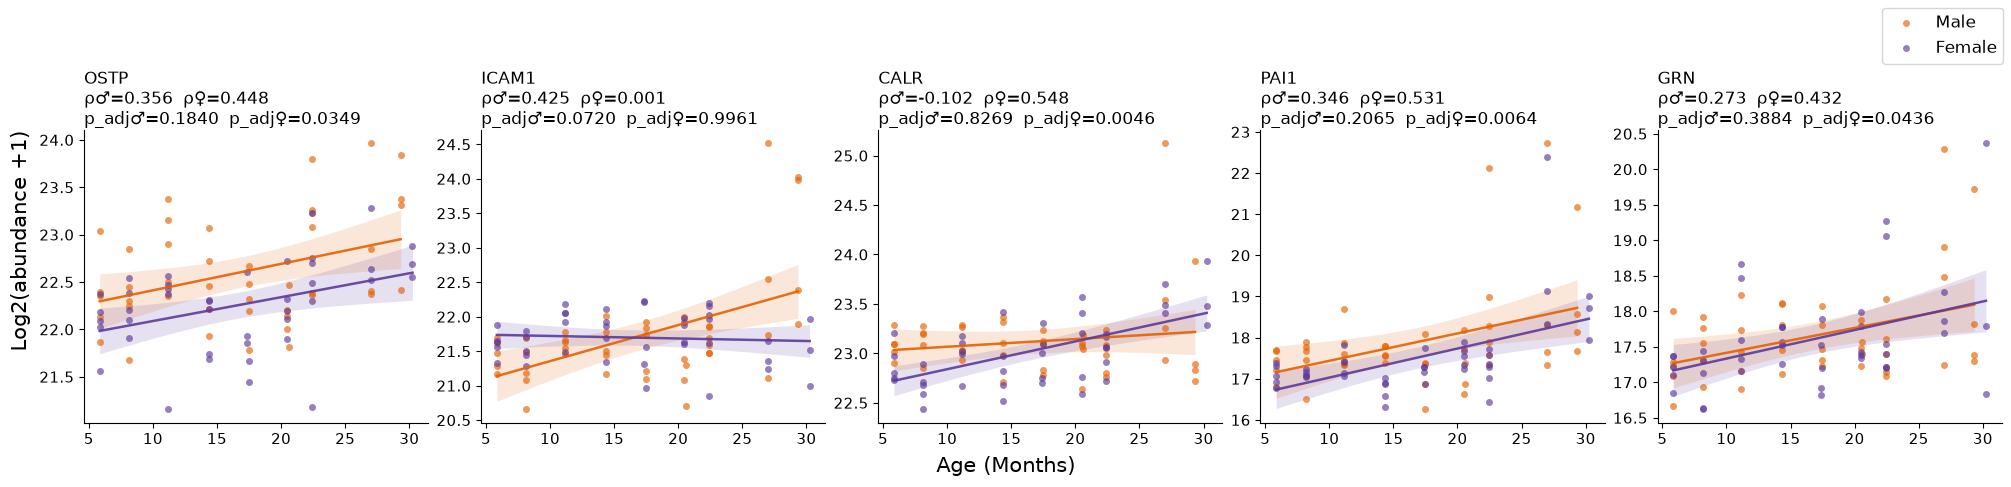

In [10]:
# Panel of individual protein age-trajectories by sex (1 row x 5 proteins).
# Same male/female colours and log2(abundance + 1) transform as the panel above.
# Each panel is titled like the larger figure (protein name + per-sex Spearman rhos),
# but the third line reports the per-sex BH-adjusted Spearman p-values instead of the FDR.
# The per-sex OLS fit lines include 95% confidence-interval shading.
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t as _t_dist
from statsmodels.stats.multitest import multipletests

panel_proteins = ["OSTP", "ICAM1", "CALR", "PAI1", "GRN"]
male_color = "#E66100"    # Male   (matches the panel above)
female_color = "#5D3A9B"  # Female (matches the panel above)
male_label, female_label = 0, 1  # sex encoding: 0 = Male, 1 = Female

# ---------------------------------------------------------------------------
# Benjamini-Hochberg correction of the per-sex Spearman p-values.
#
# This mirrors the analogous panel (figS4 D-H) in
# ../rmd_analysis/rmd_aging_mouse_ev_proteome_figures.Rmd, which is built by
# generate_paired_sex_corr_plots() and displays p[adj,F] / p[adj,M]. There,
# corrspear_function_ageVSabundance() drops the yeast enolase control and then calls
# p.adjust(method = "BH") on the male-only and female-only Spearman results separately,
# each across the whole proteome. So, matching that:
#   - male and female are two INDEPENDENT correction families (they are never pooled), and
#   - each family spans all 2574 proteins, not just the five plotted here.
#
# The raw p-values need no recomputation: R's cor.test(method = "spearman",
# exact = FALSE, continuity = FALSE) uses the same asymptotic t approximation
# (t = rho * sqrt((n - 2) / (1 - rho^2)), df = n - 2) that produced p_male / p_female.
# Note the R script also drops the IEQC/IBQC controls, but those are *samples* -- they
# are already excluded here by the Age_months filter and do not change the family size.
# ---------------------------------------------------------------------------
YEAST_CONTROL = "sp|P00924|ENO1_YEAST"  # excluded by the R script's filter()

stats_bh = stats[stats["protein"] != YEAST_CONTROL].copy()
for _sex_name in ("male", "female"):
    stats_bh[f"p_adj_{_sex_name}"] = multipletests(
        stats_bh[f"p_{_sex_name}"].values, method="fdr_bh"
    )[1]
print(f"BH correction applied within each sex across {len(stats_bh)} proteins "
      f"(all proteins except {YEAST_CONTROL})")


def _protein_col_index(target):
    """Column index in `protein_names` whose UniProt entry name matches `target`."""
    for i, full in enumerate(protein_names):
        for member in str(full).split(" / "):
            parts = member.split("|")
            entry = parts[2] if len(parts) >= 3 else member
            if entry.split("_")[0] == target:
                return i
    raise ValueError(f"Protein '{target}' not found in protein_names")


def _ols_fit_ci(tx, ty, ci=0.95, npts=200):
    """OLS fit over the finite (tx, ty) pairs.

    Returns (x_line, y_line, lower, upper) where lower/upper bound the
    ``ci`` confidence band for the *mean response* (the regression line),
    or None if there are too few points to fit.
    """
    m = np.isfinite(tx) & np.isfinite(ty)
    x, yv = tx[m], ty[m]
    n = x.size
    xbar = x.mean()
    sxx = np.sum((x - xbar) ** 2)
    if n < 3 or sxx == 0:
        return None
    slope, intercept = np.polyfit(x, yv, 1)
    dof = n - 2
    resid = yv - (intercept + slope * x)
    s_err = np.sqrt(np.sum(resid ** 2) / dof)                 # residual standard error
    tval = _t_dist.ppf(0.5 + ci / 2.0, dof)                   # two-sided critical value
    x_line = np.linspace(x.min(), x.max(), npts)
    y_line = intercept + slope * x_line
    half = tval * s_err * np.sqrt(1.0 / n + (x_line - xbar) ** 2 / sxx)
    return x_line, y_line, y_line - half, y_line + half


def _fmt_rho(val):
    try:
        return f"{float(val):.3f}"
    except (TypeError, ValueError):
        return "nan"


def _fmt_p(val):
    try:
        v = float(val)
        return f"{v:.2e}" if v < 0.001 else f"{v:.4f}"
    except (TypeError, ValueError):
        return "nan"


# Per-protein Spearman rhos / BH-adjusted p-values (BH computed just above)
stats_by_protein = stats_bh.set_index("protein")

male_mask = (sex == male_label)
female_mask = (sex == female_label)

fig, axes = plt.subplots(1, len(panel_proteins), figsize=(20, 4.8),
                         layout="constrained")

for ax, prot in zip(axes, panel_proteins):
    col = _protein_col_index(prot)
    full_name = str(protein_names[col])
    srow = stats_by_protein.loc[full_name]

    y = np.log2(np.maximum(X[:, col], 0) + 1)  # log2(abundance + 1), as in the panel above

    ax.scatter(month[male_mask], y[male_mask], color=male_color,
               alpha=0.65, s=25, linewidths=0, zorder=3, label="Male")
    ax.scatter(month[female_mask], y[female_mask], color=female_color,
               alpha=0.65, s=25, linewidths=0, zorder=3, label="Female")

    # OLS fit line + 95% confidence-interval band per sex
    for grp_mask, grp_color in ((male_mask, male_color), (female_mask, female_color)):
        fit = _ols_fit_ci(month[grp_mask], y[grp_mask], ci=0.95)
        if fit is not None:
            x_line, y_line, lo, hi = fit
            ax.fill_between(x_line, lo, hi, color=grp_color, alpha=0.15,
                            linewidth=0, zorder=1)
            ax.plot(x_line, y_line, color=grp_color, linewidth=1.8, alpha=0.9, zorder=4)

    ax.set_title(
        f"{short_protein_label(full_name)}\n"
        f"ρ♂={_fmt_rho(srow['rho_male'])}  ρ♀={_fmt_rho(srow['rho_female'])}\n"
        f"p_adj♂={_fmt_p(srow['p_adj_male'])}  p_adj♀={_fmt_p(srow['p_adj_female'])}",
        fontsize=12, loc="left", pad=4,
    )
    ax.tick_params(labelsize=11)
    ax.spines[["top", "right"]].set_visible(False)

# Single shared axis labels for the whole panel (instead of per-plot labels)
fig.supxlabel("Age (Months)", fontsize=15)
fig.supylabel("Log2(abundance +1)", fontsize=15)

# One shared Male/Female legend for the whole panel
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside upper right", fontsize=12)

# Save alongside the other manuscript figures, using the same dpi / tight bounding
# box as visualize_sex_diff() above. Saved before plt.show() so the figure is
# written whatever the active backend does on display.
panel_base = "results/aging-marker-proteins-by-sex"
_exts = ("svg", "pdf", "png")  # same set visualize_sex_diff() writes
for _ext in _exts:
    fig.savefig(f"{panel_base}.{_ext}", dpi=150, bbox_inches="tight", format=_ext)
print(f"Saved panel to {panel_base}.{{{','.join(_exts)}}}")

plt.show()